In [1]:
# Import necessary libraries
import pandas as pd
from IPython.utils.text import re
from numpy import size
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv('products_asos.csv')

# Display the first few rows of the dataset
df.head()

,url,name,size,category,price,color,sku,description,images
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...


In [3]:
df.columns # checking the columns of the dataset

Index(['url', 'name', 'size', 'category', 'price', 'color', 'sku',
       'description', 'images'],
      dtype='object')

In [4]:
df.describe() # getting the statistical summary of the dataset

,sku
count,3.082700e+04
mean,1.154976e+08
std,2.259336e+07
min,4.010200e+05
25%,1.173468e+08
50%,1.199234e+08
75%,1.228726e+08
max,1.292616e+08


In [5]:
df.info() # getting the information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30845 entries, 0 to 30844
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   url          30827 non-null  object 
 1   name         30827 non-null  object 
 2   size         30827 non-null  object 
 3   category     30827 non-null  object 
 4   price        30827 non-null  object 
 5   color        30827 non-null  object 
 6   sku          30827 non-null  float64
 7   description  30827 non-null  object 
 8   images       30827 non-null  object 
dtypes: float64(1), object(8)
memory usage: 2.1+ MB


In [6]:
# Check for missing values in the 'price' column
df['price'].isnull().sum()

np.int64(18)

In [7]:
# Convert the 'price' column to numeric, coercing errors to NaN
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Drop rows with missing values in the 'price' column and create a new DataFrame
df_asos = df.dropna(subset=['price']).copy()
print(f"Data Loaded: {len(df_asos)} rows")
df_asos.head()

Data Loaded: 18378 rows


,url,name,size,category,price,color,sku,description,images
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...


In [8]:
# Convert the 'description' column to string type and handle any potential issues with non-string values
df_asos['description'] = df_asos['description'].astype(str)

In [9]:
# Define a function to extract the brand from the description
def get_brand(text):
  if 'by' in text:   # Check if 'by' is in the text
    try:
      return text.split('by ')[1].split(' ')[0].strip().title() # Extract the brand name after 'by' and format it
    except: 
      return "Unknown"  # If there's an error in extraction, return "Unknown"
  else:
    return "Unknown"    # If 'by' is not in the text, return "Unknown"

# Apply the get_brand function to the 'description' column to create a new 'brand_raw' column
df_asos['brand_raw'] = df_asos['description'].apply(get_brand)

In [10]:
# Convert the 'brand_raw' column to lowercase for consistent mapping
df_asos['brand_raw'] = df_asos['brand_raw'].str.lower()

# Create a mapping of raw brand names to standardized brand names
brand_map = {
    'new': 'New Look',
    'river': 'River Island',
    'miss': 'Miss Selfridge',
    'topshopwelcome': 'Topshop',
    'asos': 'ASOS',
    'adidas': 'Adidas',
    'vero': 'Vero Moda',
    'collusionexclusive': 'Collusion'
}

# Map the raw brand names to standardized brand names using the brand_map dictionary, and fill any unmapped values with the title-cased version of the raw brand name
df_asos['Brand'] = df_asos['brand_raw'].map(brand_map).fillna(df_asos['brand_raw'].str.title())
brand_counts = df_asos['Brand'].value_counts() # Count the occurrences of each brand
valid_brands = brand_counts[brand_counts >= 10].index # Filter the DataFrame to include only rows with valid brands (those with at least 10 occurrences)
df_clean = df_asos[df_asos['Brand'].isin(valid_brands)].copy() # Create a new DataFrame with only valid brands

print(df_clean['Brand'].value_counts().head(8))# Display the top 8 brands by count


Brand
ASOS              4844
Topshop           1017
New Look           511
River Island       467
Miss Selfridge     429
Adidas             384
Collusion          364
Vero Moda          327
Name: count, dtype: int64


In [11]:
# Function to analyze stockouts
def calculate_phantom_revenue(size_str): # Define a function to calculate stockout count and rate
  if not isinstance(size_str, str):      # Check if the input is not a string
    return 0, 0.0                        # If not a string, return 0 count and 0.0 rate

  # Split "UK 6, UK 8 - Out of stock" into list
  size = size_str.split(',')    # Split the size string into a list of sizes
  total_size = len(size)        # Get the total number of sizes available

  # Count how many items are out of stock
  out_of_stock_count = size_str.count('Out of stock') # Count the occurrences of 'Out of stock' in the size string

  # Calculate Rate (0.0 to 1.0)
  rate = out_of_stock_count / total_size if total_size > 0 else 0.0   # Calculate the stockout rate as the ratio of out-of-stock items to total sizes, ensuring no division by zero

  return out_of_stock_count, rate       # Return the count of out-of-stock items and the stockout rate



# Apply the calculate_phantom_revenue function to the 'size' column and create new columns for stockout count and rate
metrics = df_clean['size'].apply(lambda x: calculate_phantom_revenue(x))

# Create a new column 'Stockout_Count' in df_clean by applying the calculate_phantom_revenue function to the 'size' column and extracting the first element (count) from the returned tuple.
df_clean['Stockout_Count'] = metrics.apply(lambda x: x[0])

# Create a new column 'Stockout_Rate' in df_clean by applying the calculate_phantom_revenue function to the 'size' column and extracting the second element (rate) from the returned tuple.
df_clean['Stockout_Rate'] = metrics.apply(lambda x: x[1])

# Calculate Lost Revenue by multiplying the 'price' column with the 'Stockout_Count' column and store the result in a new column 'Lost_Revenue'.
df_clean['Lost_Revenue'] = df_clean['price'] * df_clean['Stockout_Count'] 


cols = ['Brand', 'name', 'price', 'Stockout_Count', 'Lost_Revenue'] # Define the columns to display

# Display the top 10 products with the highest lost revenue, sorted in descending order by 'Lost_Revenue'.
print(df_clean[cols].sort_values(by='Lost_Revenue', ascending=False).head(10)[cols])

           Brand                                               name  price  \
21948    Topshop  Topshop premium real leather collared zip thro...  260.0   
2715        ASOS  ASOS DESIGN premium real leather trench coat i...  220.0   
15584       ASOS  ASOS EDITION geo embellished fringe plunge mid...  250.0   
29838    Topshop           Topshop Baggy co-ord jeans in green cord   50.0   
1269   Allsaints    AllSaints Balfern leather biker jacket in black  319.0   
16047       ASOS  ASOS EDITION Curve all over floral embroidered...  210.0   
6566        ASOS  ASOS EDITION all over floral embroidered maxi ...  210.0   
3413         The  The North Face 1996 Retro Nuptse down jacket i...  300.0   
3128         The  The North Face 1996 Retro Nuptse down puffer j...  300.0   
30101       ASOS  ASOS DESIGN Bridesmaid ruched bodice drape max...   85.0   

       Stockout_Count  Lost_Revenue  
21948               7        1820.0  
2715                7        1540.0  
15584               6      

In [12]:
# Group the cleaned DataFrame by 'Brand' and calculate the average price, average stockout count, total lost revenue, and total number of products for each brand. Reset the index to convert the grouped data back into a DataFrame.
brand_strategy = df_clean.groupby('Brand').agg({
    'price': 'mean',
    'Stockout_Count': 'mean',
    'Lost_Revenue': 'sum',
    'name': 'count'
}).reset_index()

# Rename the columns of the brand_strategy DataFrame for clarity and filter out brands with 10 or fewer products.
brand_strategy.columns = ['Brand', 'Avg_Price', 'Avg_Stockout_Count', 'Total_Lost_Revenue', 'Total_Products']
brand_strategy = brand_strategy[brand_strategy['Total_Products'] > 10] 


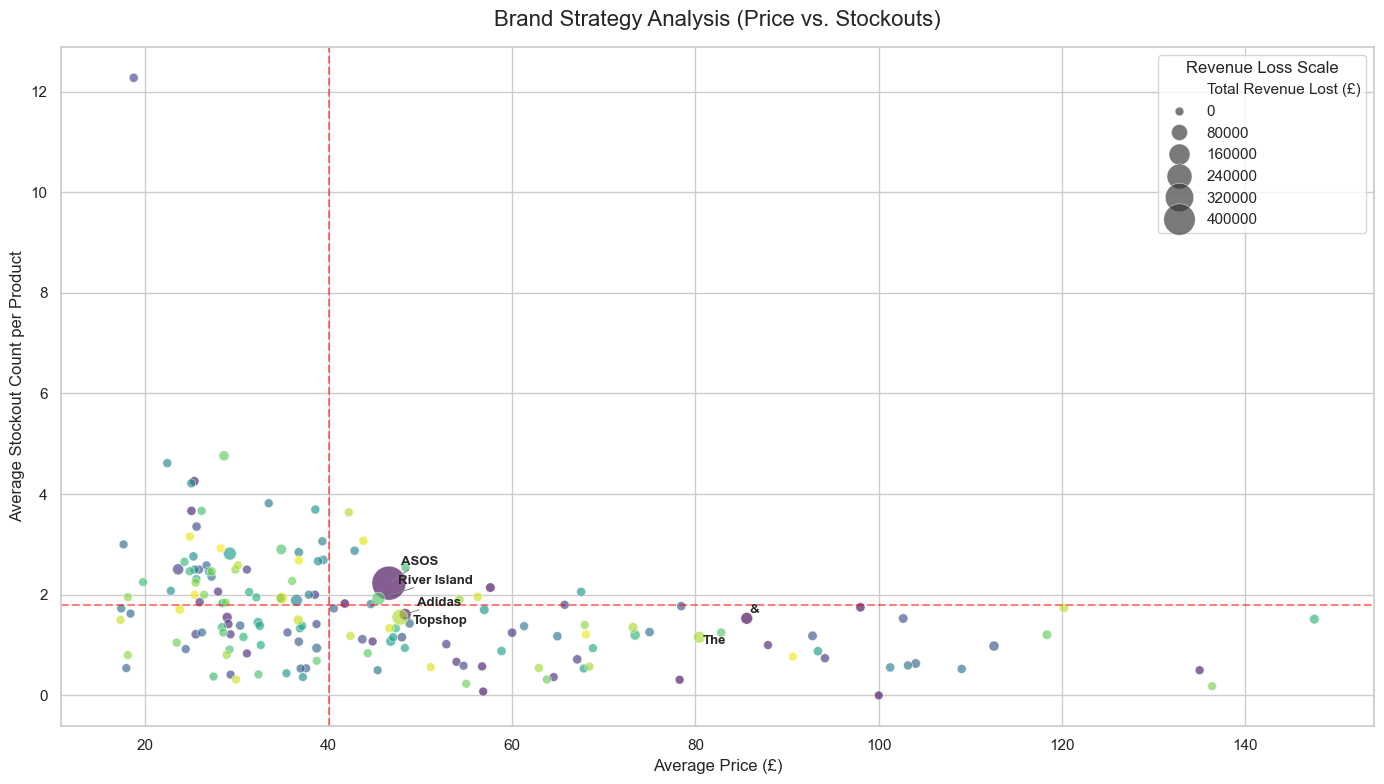

In [13]:
# Import the adjustText library for adjusting text labels in the plot
from adjustText import adjust_text

#  Set a clean style and figure size
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

#  Plot the scatter points WITH brief legend enabled
sns.scatterplot(
    data=brand_strategy,
    x='Avg_Price',                      # X-axis represents the average price of products for each brand
    y='Avg_Stockout_Count',             # Y-axis represents the average stockout count per product for each brand
    size='Total_Lost_Revenue',          # Size of the points represents the total lost revenue for each brand
    sizes=(40, 600),                    # Size range for the points, from 40 to 600
    alpha=0.65,                         #
    hue='Brand',
    palette='viridis',
    legend='brief'          # Tells seaborn to generate a data-based legend
)

#  Filter for heavy-hitting revenue losers
winners = brand_strategy[                               # Create a new DataFrame 'winners' that contains only the brands that meet the following criteria:
    (brand_strategy['Avg_Price'] > 40) &                # Select brands with an average price greater than £40
    (brand_strategy['Total_Lost_Revenue'] > 20000)      # Select brands with total lost revenue greater than £20,000
]

#  Generate text objects with bold styling
texts = []                                              # Initialize an empty list to store text objects
for i, row in winners.iterrows():                       # Loop through each row in the 'winners' DataFrame to create text labels for the scatter plot
    texts.append(                                       # Add a text label to the 'texts' list for each brand that meets the criteria
        plt.text(                                       # Add a text label to the plot at the specified coordinates
            row['Avg_Price'],                           # X-coordinate for the text label, corresponding to the average price of the brand
            row['Avg_Stockout_Count'],                  # Y-coordinate for the text label, corresponding to the average stockout count of the brand
            row['Brand'],                               # Text content for the label, corresponding to the brand name
            fontsize=9.5,
            weight='bold'
        )
    )

#  Automatically space out overlapping text labels
adjust_text(texts, arrowprops=dict(arrowstyle="->", color='gray', lw=0.7))

#  Customize labels, titles, and quadrant lines
plt.title('Brand Strategy Analysis (Price vs. Stockouts)', fontsize=16, pad=15)
plt.xlabel('Average Price (£)', fontsize=12)
plt.ylabel('Average Stockout Count per Product', fontsize=12)

# Strategic boundaries
plt.axvline(x=40, color='red', linestyle='--', alpha=0.5)
plt.axhline(y=1.8, color='red', linestyle='--', alpha=0.5)

# Customize the legend to only show relevant size categories and rename the header for clarity
handles, labels = plt.gca().get_legend_handles_labels() # handles: list of legend handles (the visual elements in the legend)

# We only keep the headers and the size bubbles (usually the first few or last few elements)
# Since 'Total_Lost_Revenue' is numerical, its size keys are always numbers or the header string
clean_handles = []  # List to store the filtered legend handles
clean_labels = []   # List to store the filtered legend labels

for h, l in zip(handles, labels):  # Iterate through the handles and labels
    # Only keep the 'Total_Lost_Revenue' label and the actual numeric size categories
    if l == 'Total_Lost_Revenue' or l.replace('.', '', 1).isdigit():  # Check if the label is 'Total_Lost_Revenue' or a numeric value (size category)
        clean_handles.append(h)    # Add the corresponding handle to the clean_handles list
        clean_labels.append(l)     # Add the corresponding label to the clean_labels list

# Rename the header so it looks perfect
if clean_labels and clean_labels[0] == 'Total_Lost_Revenue':   # Check if the first label in the clean_labels list is 'Total_Lost_Revenue'
    clean_labels[0] = 'Total Revenue Lost (£)'                 # Rename the header for clarity

# Display the perfectly curated, compact size legend
plt.legend(clean_handles, clean_labels, loc='upper right', title='Revenue Loss Scale')  # Tells matplotlib to create a legend using the filtered handles and labels, placing it in the upper right corner of the plot with the title 'Revenue Loss Scale'

plt.tight_layout()  # Adjust the layout to prevent clipping of labels
plt.show()

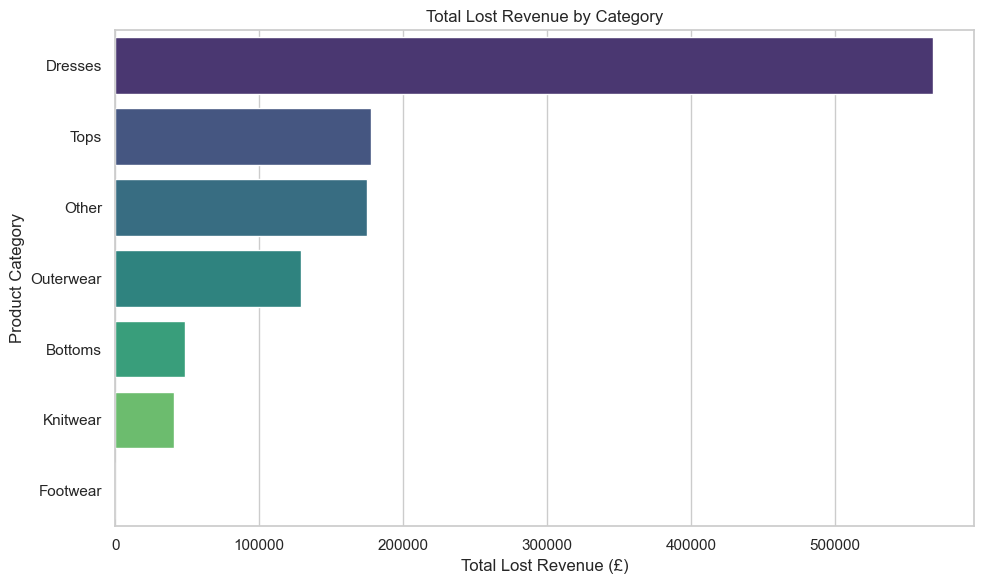

In [14]:
#  Define category keywords
def get_type(text):                                         # Define a function to categorize product types based on keywords in the text
    text = str(text).lower()                                # Convert the text to lowercase for case-insensitive matching
    if "dress" in text:                                     # Check if the word "dress" is in the text
        return "Dresses"                                    # Return "Dresses" if the keyword is found
    elif "coat" in text or "jacket" in text:                # Check if the words "coat" or "jacket" are in the text
        return "Outerwear"                                  # Return "Outerwear" if either keyword is found
    elif "top" in text or "shirt" in text:                  # Check if the words "top" or "shirt" are in the text
        return "Tops"                                       # Return "Tops" if either keyword is found
    elif "jeans" in text or "trouser" in text:              # Check if the words "jeans" or "trouser" are in the text
        return "Bottoms"                                    # Return "Bottoms" if either keyword is found
    elif "shoe" in text or "boot" in text:                  # Check if the words "shoe" or "boot" are in the text
        return "Footwear"                                   # Return "Footwear" if either keyword is found
    elif "jumper" in text or "sweater" in text:             # Check if the words "jumper" or "sweater" are in the text
        return "Knitwear"                                   # Return "Knitwear" if either keyword is found
    else:
        return "Other"                                      # Return "Other" if no keywords are found


#  Extract item types
df_clean["Item_Type"] = df_clean[    # Create a new column 'Item_Type' in df_clean by applying the get_type function to the 'category' column, which categorizes products based on keywords in their category descriptions.
    "category"
].apply(get_type)

#  Aggregate lost revenue
cat_revenue = (                      # Create a new DataFrame 'cat_revenue' that contains the total lost revenue for each item type by grouping the cleaned DataFrame by 'Item_Type', summing the 'Lost_Revenue' for each group, resetting the index to convert the grouped data back into a DataFrame, and sorting the values in descending order by 'Lost_Revenue'.
    df_clean.groupby("Item_Type")
    ["Lost_Revenue"]
    .sum()
    .reset_index()
    .sort_values(
        by="Lost_Revenue",
        ascending=False,
    )
)

#  Plot the horizontal bar chart
plt.figure(figsize=(10, 6))    # Setting the figure size for the bar chart to 10 inches wide and 6 inches tall
sns.barplot(                   # Using seaborn's barplot function to create a horizontal bar chart that visualizes the total lost revenue by product category, with the x-axis representing the total lost revenue in pounds and the y-axis representing the product categories, and applying the 'viridis' color palette for better visual distinction.
    data=cat_revenue,
    x="Lost_Revenue",
    y="Item_Type",
    hue="Item_Type", # note: This line adds a color gradient to the bars based on the 'Lost_Revenue' values, enhancing visual differentiation between categories with different revenue losses.
    legend=False,
    palette="viridis"
)
plt.title("Total Lost Revenue by Category")
plt.xlabel("Total Lost Revenue (£)")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

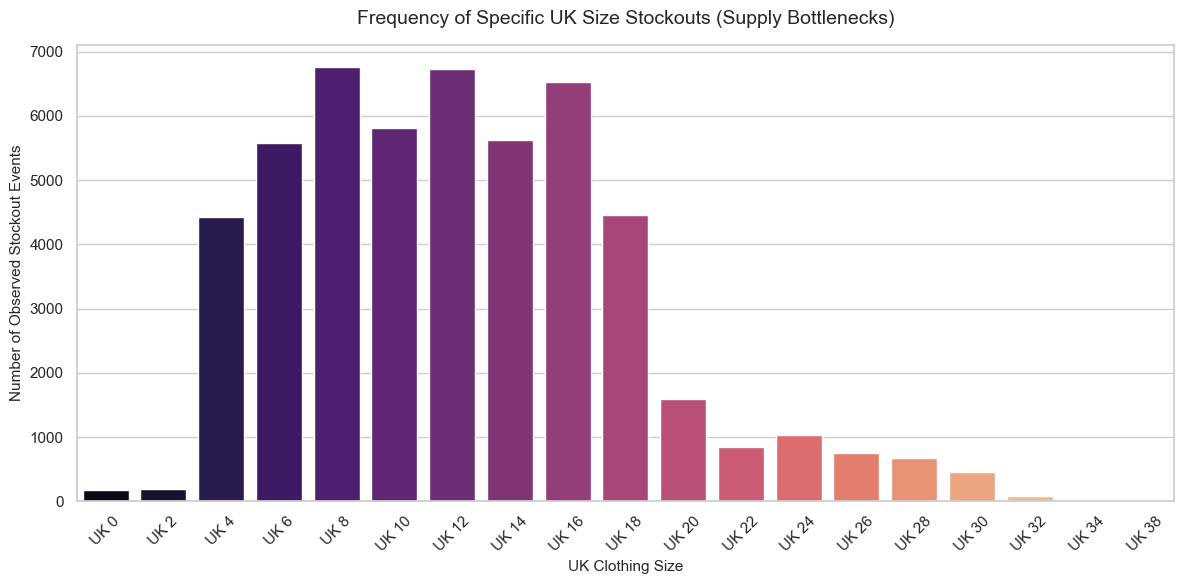

In [15]:
# Function to isolate standard UK clothing sizes
def extract_uk_sizes(size_str):             # Define a function to extract standard UK clothing sizes from a given string
    if not isinstance(size_str, str):       # Check if the input is not a string
        return []                           # Return an empty list if the input is not a string

    # Find common patterns like 'UK 6', 'UK 10', etc.
    import re  # Import the regular expressions module to use for pattern matching

    sizes = re.findall(r"\bUK\s\d+\b", size_str)
    return sizes


#  Explode the dataset so every out-of-stock size gets its own row
# (We only look at instances where the text confirms "Out of stock")
df_clean["size_str_lower"] = df_clean["size"].astype(str).str.lower()
out_of_stock_rows = df_clean[df_clean["size_str_lower"].str.contains("out of stock")].copy()  # Create a new DataFrame 'out_of_stock_rows' that contains only the rows from df_clean where the 'size_str_lower' column contains the phrase "out of stock", indicating that the product is out of stock in certain sizes.

# Extract sizes that are missing
out_of_stock_rows["OOS_Sizes"] = out_of_stock_rows["size"].apply(   
    extract_uk_sizes
)
exploded_sizes = out_of_stock_rows.explode("OOS_Sizes") 

#  Clean up any lingering NaNs and aggregate the count
exploded_sizes = exploded_sizes.dropna(subset=["OOS_Sizes"])
size_counts = (
    exploded_sizes["OOS_Sizes"]
    .value_counts()
    .reset_index(name="Stockout_Occurrences")
)

# Sort standard sizes numerically (e.g., UK 4, UK 6, UK 8...)
size_counts["Size_Num"] = (
    size_counts["OOS_Sizes"].str.extract(r"(\d+)").astype(int)
)
size_counts = size_counts.sort_values(by="Size_Num")

#  Plot the results
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.barplot(
    data=size_counts,
    x="OOS_Sizes",
    y="Stockout_Occurrences",
    hue="OOS_Sizes",  
    palette="magma",
    legend=False,
)

plt.title(
    "Frequency of Specific UK Size Stockouts (Supply Bottlenecks)",
    fontsize=14,
    pad=15,
)
plt.xlabel("UK Clothing Size", fontsize=11)
plt.ylabel("Number of Observed Stockout Events", fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

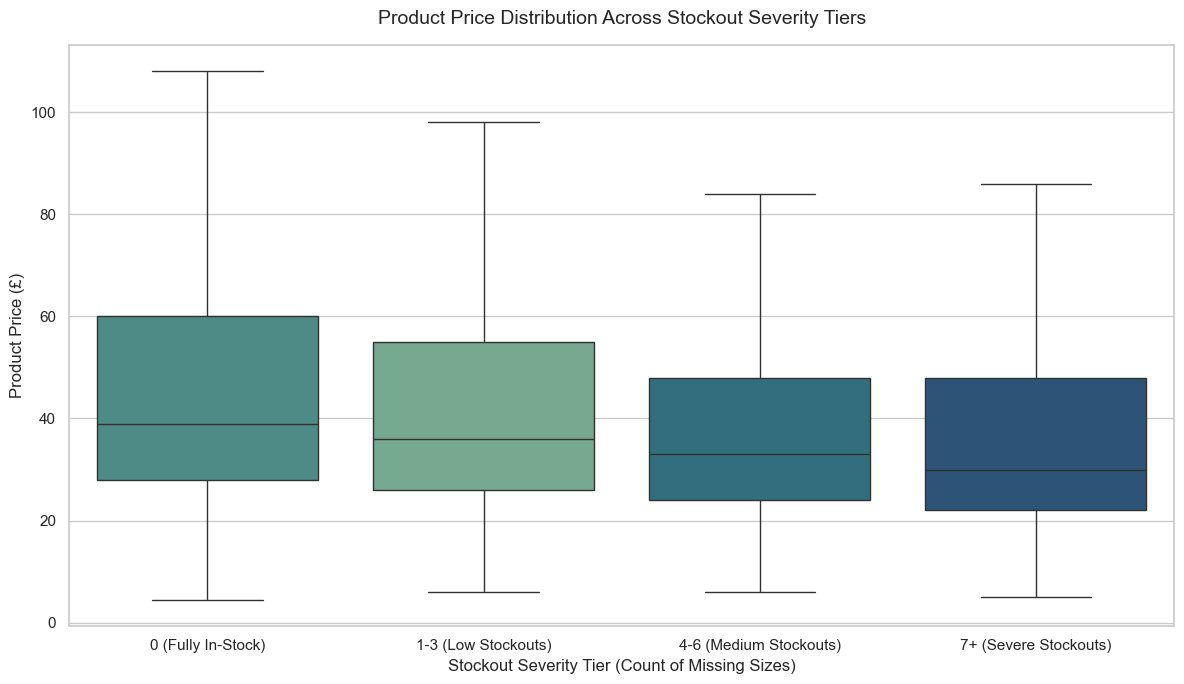

<Figure size 640x480 with 0 Axes>

In [ ]:
#  Create stockout categories to group our data
def categorize_stockouts(count):        # Define a function to categorize stockout counts into severity tiers
    if count == 0:                      
        return "0 (Fully In-Stock)"     
    elif 1 <= count <= 3:
        return "1-3 (Low Stockouts)"
    elif 4 <= count <= 6:
        return "4-6 (Medium Stockouts)"
    else:
        return "7+ (Severe Stockouts)"


df_clean["Stockout_Severity"] = df_clean["Stockout_Count"].apply(
    categorize_stockouts
)

#  Sort the categories so they appear in logical order on the plot
severity_order = [                              # Define the order of stockout severity categories for consistent plotting
    "0 (Fully In-Stock)",                       # The first category represents products that are fully in stock with no stockouts.
    "1-3 (Low Stockouts)",                      # The second category represents products with low stockouts, where 1 to 3 sizes are out of stock.
    "4-6 (Medium Stockouts)",                   # The third category represents products with medium stockouts, where 4 to 6 sizes are out of stock.    
    "7+ (Severe Stockouts)",                    # The fourth category represents products with severe stockouts, where 7 or more sizes are out of stock.
]

#  Plot the Boxplot
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

sns.boxplot(
    data=df_clean,
    x="Stockout_Severity",
    y="price",
    order=severity_order,
    hue="Stockout_Severity",
    palette="crest",
    showfliers=False,  # This hides extreme outliers so we can focus on the box distribution
    legend=False,
)

plt.title(
    "Product Price Distribution Across Stockout Severity Tiers",
    fontsize=14,
    pad=15,
)
plt.xlabel("Stockout Severity Tier (Count of Missing Sizes)", fontsize=12)
plt.ylabel("Product Price (£)", fontsize=12)

plt.tight_layout()
plt.show()